# TCLAB_CLP_PID_FF


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

%config InlineBackend.figure_formats ="svg"
from package_DBR import *
from package_TCLAB import *
from package_LAB import *


import tclab
import time
from datetime import datetime
import os


## Simulation parameters

# signals

In [15]:
#Point de fonctionnement

MV0 = 50
PV0 = 54
DV0 = 50

#Parametre maniupulated value

Kp = 0.374684
T1_p = 171.145985
T2_p = 26.74464
theta_p = 12.00844


#Parmetre Disturbance Value

Kd = 0.3933681
T1_d= 161.75194
T2_d= 36.287948
theta_d= 19.570305



#IMC TUNING
gamma = 0.5
Kc,Ti,Td = IMC_Tuning(Kp, gamma, theta_p, T1_p, T2_p, 2)
Kc = Kc *0.5
Ti = 0.75 *Ti



alpha = 0.9
MVMin = 0
MVMax = 100
TSim = 1700
Ts = 1
N = int(TSim/Ts) + 1


print("kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)






kc =  2.380060965448063
Ti =  148.41796875
Td =  23.13013947108611


In [ ]:
scenario = "CLP+noFF"



# Scenario 1: CLP + FF
if scenario == "CLP+FF":
    
    ManPath = {0: True, 150: False, TSim: False} 
    MVManPath = {0: MV0+15, TSim: MV0+15} 
    
    SPPath = {0: PV0+10, 900: PV0+5, TSim: PV0+5} 
    DVPath = {0: DV0, 1100: DV0+20, 1200: DV0, TSim: DV0}
    
    ActivateFF = True
    ManFF = False

# Scenario 2: CLP + no FF
if scenario == "CLP+noFF":
    # ManPath = {0: True, 500: False, TSim: False} 
    # MVManPath = {0: MV0, TSim: MV0} 
    # SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
    # DVPath = {0: DV0, 2500: DV0+10, TSim: DV0+10}
    # ActivateFF = False
    # ManFF = False
    ManPath = {0: True, 150: False, TSim: False} 
    MVManPath = {0: MV0+15, TSim: MV0+15} 
    
    SPPath = {0: PV0+10, 900: PV0+5, TSim: PV0+5} 
    DVPath = {0: DV0, 1100: DV0+20,  TSim: DV0+20}
    
    ActivateFF = False
    ManFF = False


# Scenario 3: OLP + no FF
if scenario == "OLP+noFF":
    ManPath = {0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath = {0: PV0, TSim: PV0}
    DVPath = {0: 50, 1200: 60,TSim: 60}
    ActivateFF = False
    ManFF = True

# Scenario 4: OLP + FF
if scenario == "OLP+FF":
    ManPath ={0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath ={0: PV0, TSim: PV0}
    DVPath = {0: 50.0, 1200: 60, TSim: 60.0}
    ActivateFF = True
    ManFF = True



## TCLAB RT

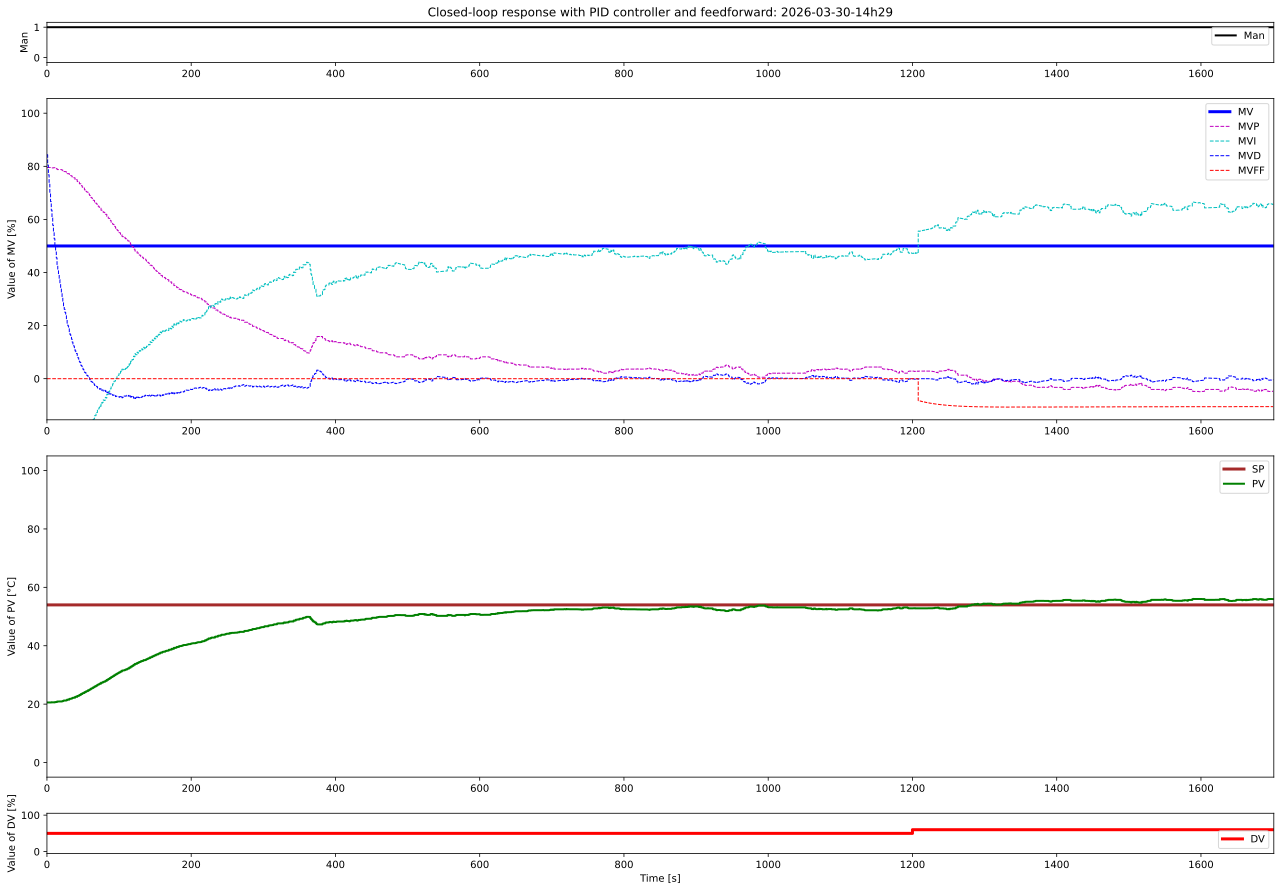

TCLab disconnected successfully.


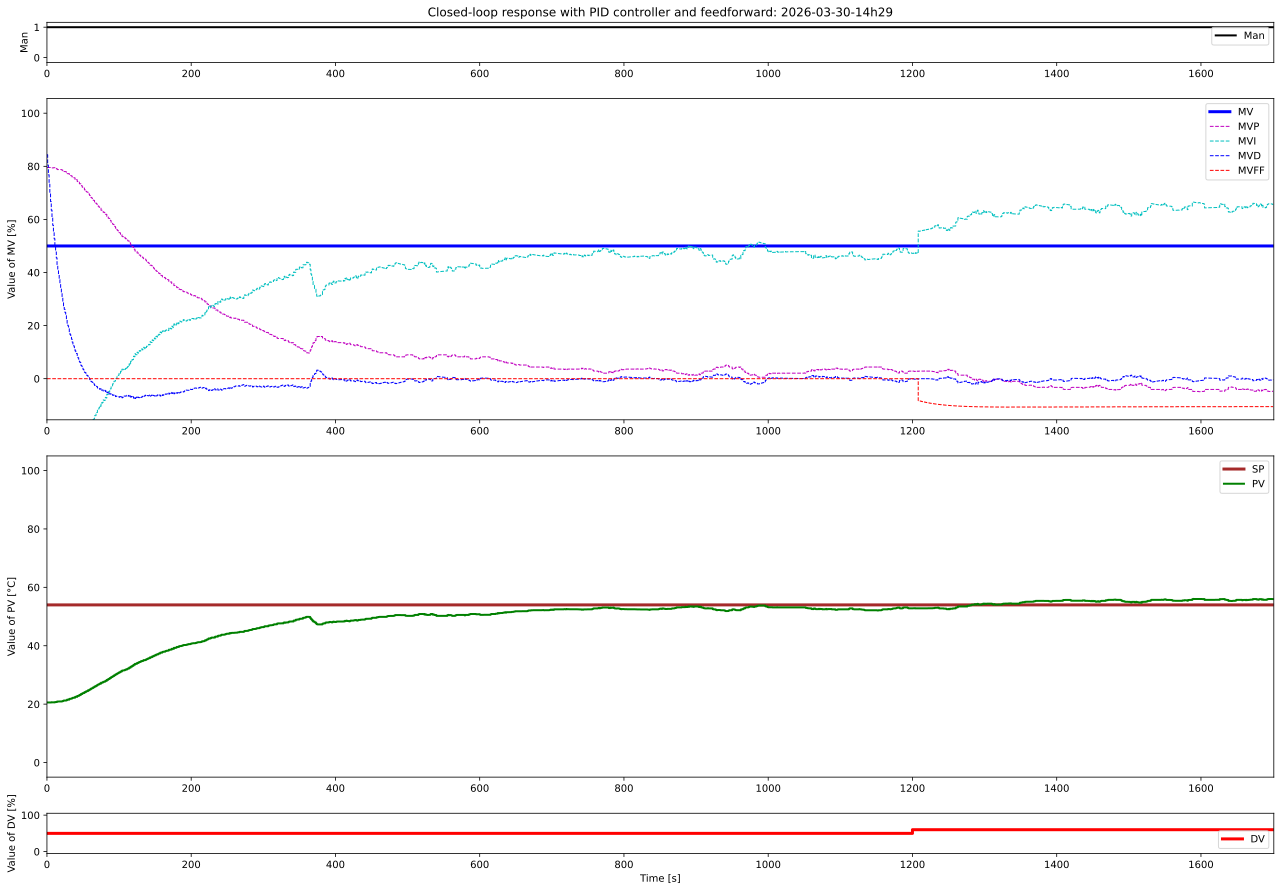

In [13]:






t = []
MV = []

MVP = []
MVI = []
MVD = []

SP=[]
MVMan=[]
MVFF = []
Man =[]
ManFF = []

DV =[]
E = []
PV = []



MVFFDelay = []
MVFFLL_output = []

MVDelayp =[]
PV1p =[]
PV2p =[]

MVDelayd =[]
PV1d =[]
PV2d =[]


lab = tclab.TCLab()

now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, gridspec_kw={'height_ratios': [1, 8, 8, 1]})
fig.set_figheight(15)
fig.set_figwidth(22)

l1, = ax1.step([0,TSim,],[-0.1,1.1],'k-',linewidth=2,label='Man',where='post')
ax1.set_ylabel('Man')
ax1.set_title('Closed-loop response with PID controller and feedforward: ' + date_time)
ax1.legend(loc='best')

l2, = ax2.step([0,TSim],[-10,100],'b-',linewidth=3,label='MV',where='post')
l3, = ax2.step([0,TSim],[-10,100],'m-',linestyle = "dashed"  ,linewidth=1,label='MVP',where='post')
l4, = ax2.step([0,TSim],[-10,100],'c-',linestyle = "dashed"  ,linewidth=1,label='MVI',where='post')
l5, = ax2.step([0,TSim],[-10,100],'b-',linestyle = "dashed"  ,linewidth=1,label='MVD',where='post')
l6, = ax2.step([0,TSim],[-10,100],'r-',linestyle = "dashed"  ,linewidth=1,label='MVFF',where='post')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='best')

l7, = ax3.step([0,TSim],[0,100],'brown',linewidth=3,label='SP',where='post')
l8, = ax3.step([0,TSim],[0,100],'g-',linewidth=2,label='PV',where='post')
ax3.set_ylabel('Value of PV [°C]')
ax3.legend(loc='best')

l9, = ax4.step([0,TSim],[0,100],'r-',linewidth=3,label='DV',where='post')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Value of DV [%]')
ax4.legend(loc='best')

for i in range(0, N):
    t.append(i*Ts)

    if len(t) == 1 :
        last_time = time.time() 

    PV.append(lab.T1)

    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(DVPath, t, DV)


    lab.Q2(DV[-1])

    

    Delay_RT(DV-DV0*np.ones_like(DV), np.max([theta_d-theta_p, 0]), Ts, MVFFDelay)
    LL_RT(MVFFDelay, -Kd/Kp, T1_p, T1_d, Ts, MVFFLL_output)

    if ActivateFF :
        LL_RT(MVFFLL_output, 1, T2_p, T2_d, Ts, MVFF)
    else :
        LL_RT(MVFFLL_output, 0, T2_p, T2_d, Ts, MVFF)



    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t, MVMan)

    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha , Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF,PV0)

    lab.Q1(MV[-1])
    

    now = time.time()
    delta = now - last_time


    time.sleep(np.max([0, Ts -delta ]))
    last_time = time.time()

    l1.set_data(t, Man)
    l2.set_data(t, MV)
    l3.set_data(t, MVP)
    l4.set_data(t, MVI)
    l5.set_data(t, MVD)
    l6.set_data(t, MVFF)

    l7.set_data(t, SP)
    l8.set_data(t, PV)

    l9.set_data(t, DV)



    clear_output(wait=True)  


    ax1.set_xlim(0, t[-1]+1)
    ax2.set_xlim(0, t[-1]+1)
    ax3.set_xlim(0, t[-1]+1)
    ax4.set_xlim(0, t[-1]+1)

    display(fig)

lab.close()

#pourrait mettre regulateur un peu plus aggresif


# Save data in text file
# ----------------------
now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")
# Conversion to array
t = np.array(t) 
MV = np.array(MV)
MVP = np.array(MVP)
MVI = np.array(MVI)
MVD = np.array(MVD)
PV = np.array(PV)
DV = np.array(DV)        
SP = np.array(SP)

my_data = np.vstack((t.T,MV.T, MVP.T, MVI.T, MVD.T ,PV.T,DV.T , SP.T ))
my_data = my_data.T
nameFile = 'Data/TCLAB_PID_FF_Test_on_' + date_time + '.txt'
if not os.path.exists('Data'):
    os.makedirs('Data')
np.savetxt(nameFile,my_data,delimiter=',',header='t,MV, MVP, MVI, MVD,PV,DV, SP',comments='')        


# Save Plot
# ---------
if not os.path.exists('Plots'):
    os.makedirs('Plots')

titleName = 'TCLAB_PID_FF_Test_on_' + date_time
plt.savefig('Plots\\' + titleName + '.png',transparent=True)
plt.savefig('Plots\\' + titleName + '.pdf',transparent=True)
    




# Plot

In [14]:
# for i in range(0, N):
#     t.append(i*Ts)

#     if len(t) == 1 :
#         last_time = time.time() 

#     PV.append(lab.T1)

#     SelectPath_RT(SPPath, t, SP)
#     SelectPath_RT(DVPath, t, DV)


#     lab.Q2(DV[-1])

#     SelectPath_RT(SPPath,t,SP)
#     SelectPath_RT(DVPath,t,DV)
    

#     Delay_RT(DV-DV0*np.ones_like(DV), np.max([theta_d-theta_p, 0]), Ts, MVFFDelay)
#     LL_RT(MVFFDelay, -Kd/Kp, T1_p, T1_d, Ts, MVFFLL_output)

#     if ActivateFF :
#         LL_RT(MVFFLL_output, 1, T2_p, T2_d, Ts, MVFF)
#     else :
#         LL_RT(MVFFLL_output, 0, T2_p, T2_d, Ts, MVFF)



#     SelectPath_RT(ManPath,t,Man)
#     SelectPath_RT(MVManPath,t, MVMan)

#     PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha , Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF,PV0)

#     lab.Q1(MV[-1])
    

#     now = time.time()
#     delta = now - last_time


#     time.sleep(np.max([0, Ts -delta ]))
#     last_time = time.time()

#     l1.set_data(t, MV)
#     l2.set_data(t, MVP)
#     l3.set_data(t, MVI)
#     l4.set_data(t, MVD)
#     l5.set_data(t, MVFF)
#     l6.set_data(t, MVFF)

#     l7.set_data(t, SP)
#     l8.set_data(t, PV)

#     l9.set_data(t, DV)



#     clear_output(wait=True)  


#     ax1.set_xlim(0, t[-1]+1)
#     ax2.set_xlim(0, t[-1]+1)
#     ax3.set_xlim(0, t[-1]+1)

#     display(fig)



# # Save data in text file
# # ----------------------
# now = datetime.now()
# date_time = now.strftime("%Y-%m-%d-%Hh%M")
# # Conversion to array
# t = np.array(t) 
# MV = np.array(MV)
# MVP = np.array(MVP)
# MVI = np.array(MVI)
# MVD = np.array(MVD)
# PV = np.array(PV)
# DV = np.array(DV)        
# SP = np.array(SP)

# my_data = np.vstack((t.T,MV.T, MVI.T, MVP.T, MVI.T, MVD.T ,PV.T,DV.T , SP.T ))
# my_data = my_data.T
# nameFile = 'Data/TCLAB_PID_FF_Test_on_' + date_time + '.txt'
# if not os.path.exists('Data'):
#     os.makedirs('Data')
# np.savetxt(nameFile,my_data,delimiter=',',header='t,MV, MVP, MVI, MVD,PV,DV, SP',comments='')        


# # Save Plot
# # ---------
# if not os.path.exists('Plots'):
#     os.makedirs('Plots')

# titleName = 'TCLAB_PID_FF_Test_on_' + date_time
# plt.savefig('Plots\\' + titleName + '.png',transparent=True)
# plt.savefig('Plots\\' + titleName + '.pdf',transparent=True)
    